# Compare the longitudinal intra donor variability of ARI and con2
- compare the variability of healthy control CON2 and ARI longitudinally
- calculate the CV for ALTRA converters and BRI healthy
- compared the CV

In [4]:
# load library
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('data.table')
quiet_library('tidyverse')
quiet_library('ggplot2')
quiet_library('Matrix')
quiet_library('dplyr')
quiet_library('viridis')
quiet_library('future')
quiet_library('future.apply')
quiet_library('PALMO')
quiet_library('scran')
quiet_library('SingleCellExperiment')
quiet_library('DESeq2')
quiet_library('ggpubr')
quiet_library('parallel')

In [5]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
ari_colors = c('#4C8CBD', '#F59F00', '#840032')
options(repr.plot.width = 20, repr.plot.height = 15)

In [3]:
# define file path
# define working path
data_path = '/home/workspace/data/ra_longitudinal/output_results/integration'
fig_path = '/home/workspace/data/ra_longitudinal/figures/integration'
meta_path = '/home/workspace/github/ra-longitudinal/metadata'
output_path = '/home/workspace/data/ra_longitudinal/output_results/certPro'

if(!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if(!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- 'ALTRA_AIM3_BRI_scRNA_PALMO_'

In [4]:
#' DEseq2Norm
#'
#' This function performs DESeq2 normalization on a given SummarizedExperiment object.
#'
#' @param pb_se A SummarizedExperiment object containing the raw counts to be normalized.
#'
#' @return A SummarizedExperiment object with an added assay containing the variance stabilized transformed counts.
#'
#' @details
#' The function first creates a DESeqDataSet object with a design formula of `~ 1`, indicating no specific design.
#' It then applies the variance stabilizing transformation (VST) to the DESeqDataSet object.
#' The resulting VST counts are added as a new assay to the input SummarizedExperiment object.
#'
#' @import DESeq2
#' @import SummarizedExperiment
#'
#' @examples
#' \dontrun{
#' library(DESeq2)
#' library(SummarizedExperiment)
#' 
#' # Example usage
#' pb_se <- SummarizedExperiment(assays = list(counts = matrix(rpois(100, lambda = 10), ncol = 10)))
#' pb_se <- DEseq2Norm(pb_se)
#' }

DEseq2Norm <- function(pb_se) {
    # get deseq2 normalized counts
    # run deseq to get normalized counts
    pb_des <- DESeqDataSet(pb_se, design = as.formula("~ 1"))
    vsd <- varianceStabilizingTransformation(pb_des, blind = TRUE)
    assay(pb_se, "vst") <- assay(vsd)
    return(pb_se)
}

#' Compare_CV
#'
#' This function performs a cross-validation (CV) comparison for a specified cell type using provided pseudobulk data.
#'
#' @param celltype_test A character string specifying the cell type to test.
#' @param pb_data A SummarizedExperiment object containing pseudobulk data.
#' @param n_cores An integer specifying the number of cores to use for parallel processing. Default is 1.
#'
#' @return A tibble containing combined CV distributions for the specified cell type, with status annotations.
#'
#' @details
#' The function filters the input data based on the specified cell type and performs several preprocessing steps,
#' including filtering low-expressed genes and normalizing the data using DESeq2. It then creates PALMO data objects
#' for both converters and healthy samples, annotates metadata, merges data, and calculates CV distributions.
#' Finally, it combines the CV distributions for converters and healthy samples and returns the result as a tibble.
#'
#' @examples
#' \dontrun{
#' # Example usage:
#' result <- Compare_CV(celltype_test = "T_cells", pb_data = pseudobulk_data, n_cores = 4)
#' }
#'
#' @import SummarizedExperiment
#' @import SingleCellExperiment
#' @import DESeq2
#' @import dplyr
#' @import PALMO
#' @import tibble
#' @importFrom magrittr %>%
#' @importFrom stats na.omit
#' @importFrom scales scale
#' @export

Compare_CV <- function(celltype_test, pb_data, n_cores = 1) {
    message(paste("processing", celltype_test))
    # filter on cell type
    pb_se <- pb_data[, colData(pb_se_lg)$cell_type == celltype_test]
    # # do some general filter to low expressed genes
    smallestGroupSize <- 30
    keep <- rowSums(assay(pb_se, "counts") >= 10) >= smallestGroupSize
    pb_se <- pb_se[keep, ]
    # run deseq2 and batch normalizatoin
    pb_se <- DEseq2Norm(pb_se)
    message(paste("processing", as.character(nrow(pb_se)), "genes"))
    pb_sce <- as(pb_se, "SingleCellExperiment")
    # subset the longitudinal ALTRA model
    pb_ra <- pb_sce[, (!is.na(colData(pb_sce)$days_to_conversion)) &
        (colData(pb_sce)$days_to_conversion > -750)]

    # create a palmo data object
    colnames(pb_ra) <- colData(pb_ra)$sample.sampleKitGuid
    expression <- assay(pb_ra, "vst")
    metadata <- colData(pb_ra) %>%
        as.data.frame() %>%
        mutate(
            Sample = sample.sampleKitGuid,
            days_to_conversion_scale = scale(days_to_conversion)
        )
    palmo_ra <- createPALMOobject(anndata = metadata, data = expression)

    palmo_ra <- annotateMetadata(
        data_object = palmo_ra,
        sample_column = "Sample",
        donor_column = "subject.subjectGuid",
        time_column = "days_to_conversion"
    )
    # Sample overlap and final matrix
    palmo_ra <- mergePALMOdata(data_object = palmo_ra, datatype = "bulk")
    # CV distribution
    cv_ra <- cvCalcBulkProfile(data_object = palmo_ra, cl = n_cores)

    # subset the longitudinal ALTRA model
    pb_bri <- pb_sce[, colData(pb_sce)$status == "BRI_healthy"]

    # create a palmo data object
    colnames(pb_bri) <- colData(pb_bri)$sample.sampleKitGuid
    expression <- assay(pb_bri, "vst")
    metadata <- colData(pb_bri) %>%
        as.data.frame() %>%
        mutate(Sample = sample.sampleKitGuid)
    palmo_bri <- createPALMOobject(anndata = metadata, data = expression)

    palmo_bri <- annotateMetadata(
        data_object = palmo_bri,
        sample_column = "Sample",
        donor_column = "subject.subjectGuid",
        time_column = "days_since_last"
    )
    # Sample overlap and final matrix
    palmo_bri <- mergePALMOdata(data_object = palmo_bri, datatype = "bulk")
    # CV distribution
    cv_bri <- suppressMessages(cvCalcBulkProfile(data_object = palmo_bri, cl = n_cores))
    # combine CV
    cv_comb <- as_tibble(cv_ra) %>%
        mutate(status = "converters") %>%
        bind_rows(as_tibble(cv_bri) %>% mutate(status = "bri_healthy")) %>%
        mutate(cell_type = celltype_test)
    return(cv_comb)
}


# load pseudobulk data for all AIMs
- inclduding BRI longitudinal

In [5]:
# load pseudobulk data for all samples
pb_se_all <- readRDS('/home/workspace/data/ra_longitudinal/output_results/integration/ALTRA_BRI_combined_AIFI_L2_pseudobulk_object.rds')

In [26]:
# add status column
pb_se_all$status = replace_na(pb_se_all$status, 'BRI_healthy')

In [27]:
# check sample number
colData(pb_se_all) %>% as_tibble() %>% 
    distinct(sample.sampleKitGuid, 
             .keep_all=TRUE) %>% group_by(status) %>% 
    tally()

status,n
<chr>,<int>
ALTRA_healthy,31
BRI_healthy,89
at_risk,31
conversion,11
early_RA,13
pre-conversion,55


In [28]:
# filter days to conversion to less than -750 days
pb_se_lg <- pb_se_all[, is.na(pb_se_all$days_to_conversion)|pb_se_all$days_to_conversion>(-750)]

In [29]:
pb_se_lg

class: SummarizedExperiment 
dim: 28879 5321 
metadata(0):
assays(1): counts
rownames(28879): A1BG A1BG-AS1 ... ZYX ZZEF1
rowData names(0):
colnames(5321): KT00070_ASDC KT03931_ASDC ... KT02536_pDC KT02540_pDC
colData names(52): index batch_id ... cell_type bmi_conv_cat

In [30]:
colData(pb_se_lg) %>% as_tibble() %>% 
    distinct(sample.sampleKitGuid, 
             .keep_all=TRUE) %>% group_by(status) %>% 
    tally()

status,n
<chr>,<int>
ALTRA_healthy,31
BRI_healthy,89
at_risk,31
conversion,11
early_RA,13
pre-conversion,49


# use PLAMO to identify the time variable genes in altra longitudinal

In [31]:
pb_sce = as(pb_se_lg, "SingleCellExperiment")
colData(pb_sce)%>%colnames()
colData(pb_sce)$status%>%unique()

[1] "index"                               "batch_id"                           
 [3] "hto_barcode"                         "hto_category"                       
 [5] "pbmc_sample_id"                      "pool_id"                            
 [7] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
 [9] "subject.subjectGuid"                 "subject.biologicalSex"              
[11] "subject.race"                        "subject.ethnicity"                  
[13] "subject.birthYear"                   "sample.visitName"                   
[15] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[17] "sample.daysSinceFirstVisit"          "file.id"                            
[19] "subset_grp"                          "predicted_doublet"                  
[21] "AIFI_L2"                             "doublets_manual"                    
[23] "Status_Xsec"                         "Status_Long"                        
[25] "anti_ccp3_finalCombined"             "days_to_conversion"                 
[27] "BMI"                                 "CMV_Status_Subj"                    
[29] "age_conv"                            "bmi_conv"                           
[31] "file.batchID"                        "status"                             
[33] "psbulk_n_cells"                      "psbulk_counts"                      
[35] "cohort"                              "AIFI_L1"                            
[37] "subject.cmv"                         "subject.bmi"                        
[39] "subject.ageAtFirstDraw"              "sample.subjectAgeAtDraw"            
[41] "specimen.specimenGuid"               "pipeline.fileGuid"                  
[43] "age"                                 "days_since_first"                   
[45] "lib_size"                            "log_lib_size"                       
[47] "age_last"                            "bmi_last"                           
[49] "last_visit_day"                      "days_since_last"                    
[51] "cell_type"                           "bmi_conv_cat"

[1] "at_risk"        "ALTRA_healthy"  "pre-conversion" "early_RA"      
[5] "conversion"     "BRI_healthy"

In [32]:
colnames(pb_sce) <- paste(colnames(pb_sce), pb_sce$cell_type, sep = '_')

# loop for all cell types

In [33]:
pb_sce

class: SingleCellExperiment 
dim: 28879 5321 
metadata(0):
assays(1): counts
rownames(28879): A1BG A1BG-AS1 ... ZYX ZZEF1
rowData names(0):
colnames(5321): KT00070_ASDC_ASDC KT03931_ASDC_ASDC ... KT02536_pDC_pDC
  KT02540_pDC_pDC
colData names(52): index batch_id ... cell_type bmi_conv_cat
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [87]:
# calculate sample number in different cell type
celltype_counts = colData(pb_se_lg)%>%as_tibble()%>%
    group_by(cell_type, cohort)%>%tally()
celltype_counts%>%head()

cell_type,cohort,n
<chr>,<chr>,<int>
ASDC,ALTRA,2
ASDC,BRI,6
CD14 monocyte,ALTRA,135
CD14 monocyte,BRI,89
CD16 monocyte,ALTRA,135
CD16 monocyte,BRI,89


In [91]:
rare_celltypes = celltype_counts%>%filter(n<15)
rare_celltypes
l2_celltypes = pb_se_all$cell_type%>%unique()
l2_celltypes = l2_celltypes[!l2_celltypes%in%rare_celltypes$cell_type]
l2_celltypes%>%length()

cell_type,cohort,n
<chr>,<chr>,<int>
ASDC,ALTRA,2
ASDC,BRI,6


[1] 28

In [ ]:
# run CV calculation with PALMO
celltype_cv <- mclapply(l2_celltypes, Compare_CV,  pb_data=pb_se_lg,
                        n_cores = 15, mc.cores = 1) %>% rbindlist()

In [ ]:
celltype_cv%>%head()

In [ ]:
celltype_cv %>% write_tsv(file.path(output_path, paste0(proj_name, 'CV_celltype.tsv')))

## analyze the cv results

In [61]:
# load cv data
celltype_cv <- fread(file.path(output_path, paste0(proj_name, 'CV_celltype.tsv')))
celltype_cv %>% head()

mean,sd,var,CV,NAs,zeros,feature,group,status,cell_type
<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
10.331672,0.21465352,0.046076133,2.077626,0,0,A1BG,CU1003,converters,CD14 monocyte
6.925017,0.10214791,0.010434195,1.475056,0,0,A1BG-AS1,CU1003,converters,CD14 monocyte
6.028399,0.20973234,0.043987654,3.479072,0,0,A2M-AS1,CU1003,converters,CD14 monocyte
7.494086,0.09604312,0.009224282,1.281585,0,0,AAAS,CU1003,converters,CD14 monocyte
6.684095,0.16929209,0.028659810,2.532760,0,0,AACS,CU1003,converters,CD14 monocyte
8.881343,0.15561135,0.024214892,1.752115,0,0,AAED1,CU1003,converters,CD14 monocyte


In [62]:
celltype_cv%>%head()

mean,sd,var,CV,NAs,zeros,feature,group,status,cell_type
<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
10.331672,0.21465352,0.046076133,2.077626,0,0,A1BG,CU1003,converters,CD14 monocyte
6.925017,0.10214791,0.010434195,1.475056,0,0,A1BG-AS1,CU1003,converters,CD14 monocyte
6.028399,0.20973234,0.043987654,3.479072,0,0,A2M-AS1,CU1003,converters,CD14 monocyte
7.494086,0.09604312,0.009224282,1.281585,0,0,AAAS,CU1003,converters,CD14 monocyte
6.684095,0.16929209,0.028659810,2.532760,0,0,AACS,CU1003,converters,CD14 monocyte
8.881343,0.15561135,0.024214892,1.752115,0,0,AAED1,CU1003,converters,CD14 monocyte


In [63]:
celltype_cv%>%distinct(feature)%>%nrow()

[1] 16032

In [64]:
celltype_cv%>%distinct(feature)%>%nrow()

[1] 16032

In [65]:
celltype_cv%>%distinct(cell_type)%>%nrow()

[1] 28

In [66]:
# remove BR2024
celltype_cv <- celltype_cv %>%filter(group!='BR2024')

In [67]:
# plot cv to mean distribution
celltype_cv%>% #filter(status=='converters')%>%
    ggplot(aes(x=mean, y=CV, color=status)) +  scattermore::geom_scattermore() +
    facet_wrap(vars(cell_type)) +
    ylim(c(0, 25)) + xlim(c(0, 15))
ggsave(file.path(fig_path, paste0(proj_name, 'CV_mean_distribution.png')), width = 12, height = 8)

Warning message:
“Removed 20669 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”


In [68]:
# calculate the ratio of CVs
celltype_cv_ratio <- celltype_cv %>% group_by(cell_type, feature, status)%>%
    summarise(mean_cv = mean(CV))%>%arrange(feature)%>%
    pivot_wider(names_from = 'status',values_from = 'mean_cv')%>%
    filter(!is.na(converters)&!is.na(bri_healthy)) %>% mutate(ratio_cv = converters/bri_healthy)%>%
    mutate(direction=factor(if_else(ratio_cv>1, 'Higher CV in ARI to Clincal RA',
                             'Higher CV in CON2'), levels=c('Higher CV in CON2', 'Higher CV in ARI to Clincal RA')))

`summarise()` has grouped output by 'cell_type', 'feature'. You can override
using the `.groups` argument.


In [69]:
celltype_cv %>% filter(group=='BR2024')

mean,sd,var,CV,NAs,zeros,feature,group,status,cell_type
<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>


In [70]:
# output the sup table 
table_s14 <- celltype_cv_ratio%>% 
    rename('cell_type'='Cell type', 'feature' = 'Gene', 'bri_healthy'='mean CV in CON2',
          'converters'='mean CV in ARI (Converters)', 
          'ratio_cv' = 'Ratio of CV (Conveters / CON2)')
table_s14%>%head()
table_s14%>%write_csv(file.path(output_path, 'TableS14_ALTRA_CON2_CV_comparison.csv'))

Cell type,Gene,mean CV in CON2,mean CV in ARI (Converters),Ratio of CV (Conveters / CON2),direction
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<fct>
CD14 monocyte,A1BG,1.426455,1.680691,1.1782292,Higher CV in ARI to Clincal RA
CD16 monocyte,A1BG,2.643327,3.135730,1.1862813,Higher CV in ARI to Clincal RA
CD56bright NK cell,A1BG,3.546346,3.003404,0.8469011,Higher CV in CON2
CD56dim NK cell,A1BG,2.365655,2.488283,1.0518368,Higher CV in ARI to Clincal RA
DN T cell,A1BG,5.534718,6.452657,1.1658510,Higher CV in ARI to Clincal RA
Effector B cell,A1BG,4.149200,4.288964,1.0336845,Higher CV in ARI to Clincal RA


In [85]:
celltype_cv_ratio %>%filter(cell_type=='cDC1')%>%dim()

[1] 2572    6

In [83]:
# calcualte the counts of genes 
cv_direction_counts = celltype_cv_ratio %>% filter(cell_type!='cDC1')%>%
    group_by(cell_type, direction)%>% tally()%>%
    mutate(counts=if_else(direction=='Higher CV in converters', -n, n), pct = prop.table(n))
cv_direction_counts%>%head()

cell_type,direction,n,counts,pct
<chr>,<fct>,<int>,<int>,<dbl>
CD14 monocyte,Higher CV in CON2,1943,1943,0.14345836
CD14 monocyte,Higher CV in ARI to Clincal RA,11601,11601,0.85654164
CD16 monocyte,Higher CV in CON2,1276,1276,0.11883032
CD16 monocyte,Higher CV in ARI to Clincal RA,9462,9462,0.88116968
CD56bright NK cell,Higher CV in CON2,535,535,0.07506665
CD56bright NK cell,Higher CV in ARI to Clincal RA,6592,6592,0.92493335


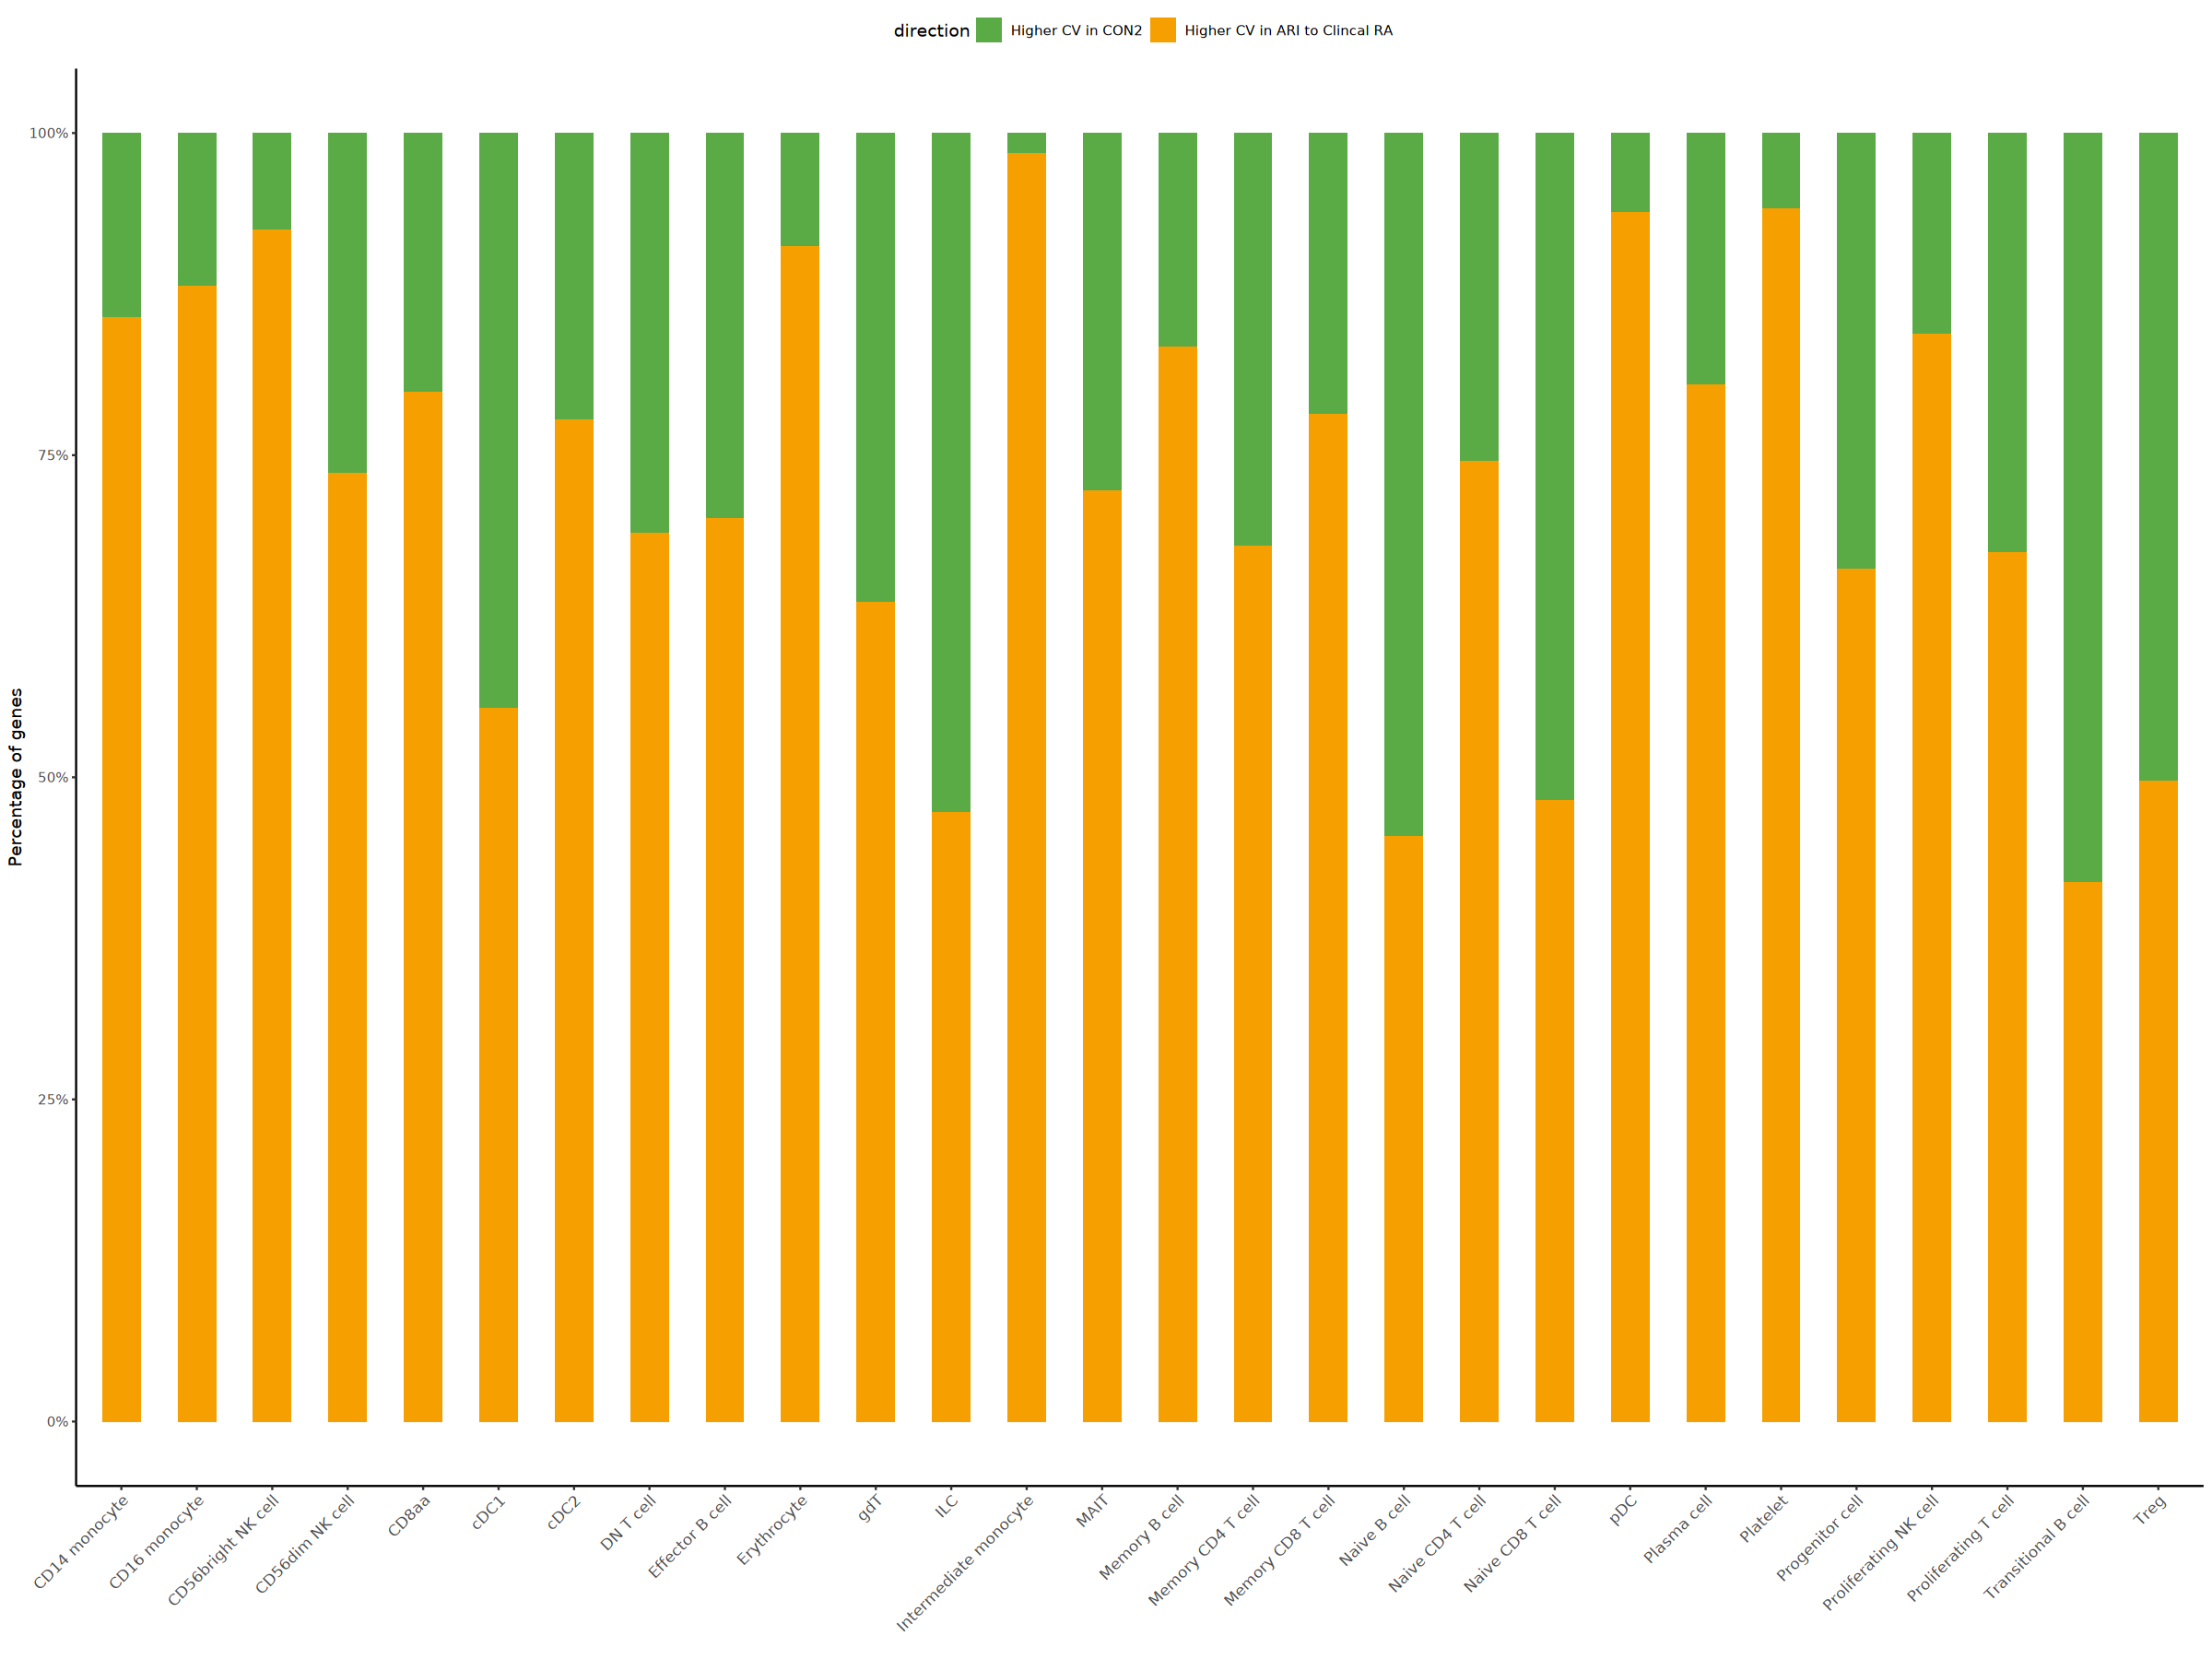

In [84]:
#plot the deg counts
p1 <- ggplot(cv_direction_counts, aes(width = 0.5, fill=direction, y=pct, x=cell_type)) +
  geom_col() +
    ylab('Percentage of genes') +
    xlab('') + theme_classic() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10),
          legend.position="top",
         strip.text = element_text(size=10))+
    scale_fill_manual(values = c('#5AAA46', 
                                '#F59F00'))+ 
    scale_y_continuous(labels = scales::percent)
p1
# Adding line to differentiate -ve and +ve y axis
# p2 <- ggpubr::ggbarplot(cv_direction_counts, xlab = 'global cell types', ylab='Number of Genes',
#                         x='cell_type', y='n', color = "direction", fill='direction',
#                         position = position_dodge(0.8),
#                         palette = c("#0072B5FF", "#BC3C29FF"))+
#     theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 12), 
#          strip.text = element_text(size=12))
# p2
#ggsave(file.path(fig_path, paste0(proj_name, 'cv_barplot_percent.pdf')), width = 6, height = 4)

In [ ]:
# calcualte the CI for forest plot
celltype_cv_ci <- celltype_cv_ratio %>% group_by(cell_type) %>% rstatix::get_summary_stats(ratio_cv)
celltype_cv_ci%>%head()

In [ ]:
lm_test<-lm(ratio_cv ~ 1, celltype_cv_ratio %>% filter(cell_type=='CD14 monocyte'))
confint(lm_test, level=0.95)

In [ ]:
# plot forest plot
p1 <- celltype_cv_ci %>% arrange(desc(mean))%>% mutate(cell_type=factor(cell_type, levels = unique(cell_type))) %>% 
    ggplot(aes(x=cell_type)) +
    geom_segment(aes(xend=cell_type, y=mean-ci, yend=mean+ci), ) +
    geom_point(aes(y=mean), size=1
               , color="orange") +
    geom_hline(yintercept = 1, color='red', linetype = "dashed") +
    ggthemes::theme_clean() +
    xlab("") + ylab('ratio of mean CV') + 
    theme(axis.text.x = element_text(
     angle = 90, vjust=0.5, hjust=1))
p1
ggsave(file.path(fig_path, paste0(proj_name, 'CV_mean_ratio_forest_plot.png')), width = 12, height = 6)

In [ ]:
mean_vc <- celltype_cv%>%group_by(cell_type, feature, status)%>%
    summarise(mean_cv = mean(CV))%>%arrange(feature) %>% ungroup()
mean_vc%>%head()

In [ ]:
# celltype_cv

In [ ]:
mean_cv_test<-celltype_cv%>%group_by(cell_type, feature, status)%>%
    summarise(mean_cv = mean(CV))%>%arrange(feature) %>% ungroup()%>%group_by(cell_type) %>% 
      rstatix::t_test(data =., mean_cv ~ status, paired = FALSE)%>%
      rstatix::adjust_pvalue(method = "BH") %>%
      rstatix::add_significance("p.adj")

In [ ]:
mean_cv_test%>%arrange(p)%>%head(10)

In [ ]:
celltype_cv_fl <- celltype_cv %>% filter(feature%in%celltype_cv_ratio$feature)

In [ ]:
celltype_cv_ratio%>%ggplot(aes(x=ratio_cv)) + geom_histogram() + facet_wrap(vars(cell_type)) + xlim(c(0, 2)) + 
    geom_vline(xintercept = 1, color='red', linetype = "dashed")
ggsave(file.path(fig_path, paste0(proj_name, 'meanCVratio_distribution.png')), width = 12, height = 8)

In [ ]:
celltype_cv_ratio%>%head()

In [ ]:
# test cv in parallel
celltypes <- celltype_cv_fl %>%distinct(cell_type) %>% pull(cell_type)
cv_stats_wilcox_test <- mclapply(celltypes, function(x){
    celltype_cv_ct <- celltype_cv_fl %>% filter(cell_type==x)
    cv_stats_wilcox_test <- celltype_cv_ct%>%
        #mutate(status=factor(status, levels = c('bri_healthy', 'converters'))) %>%
        group_by(feature) %>% 
        rstatix::wilcox_test(data =., CV ~ status, paired = FALSE)%>%
      rstatix::adjust_pvalue(method = "BH") %>%
      rstatix::add_significance("p.adj") %>% mutate(cell_type=x)
    return(cv_stats_wilcox_test)
}, mc.cores=15)%>%rbindlist()


In [ ]:
cv_stats_wilcox_test %>% filter(p.adj<0.05) %>% group_by(cell_type)%>%tally()

In [ ]:
cv_stats_wilcox_test %>% filter(p.adj<0.05&str_detect(feature, 'CD\\d|IL\\d'))

In [ ]:
cv_stats_wilcox_test %>% arrange(p.adj)%>%head()

In [ ]:
# plot one gene in one cell type
celltype_cv_test = celltype_cv%>%filter(feature=='IL17RA'&cell_type=='Intermediate monocyte')
celltype_cv_test %>% ggviolin(x='status', y='CV', add='dotplot', color='status')

In [ ]:
cv_stats_wilcox_test %>% write_tsv(file.path(output_path, paste0(proj_name, 'CV_celltype_wilcox_test.tsv')))

In [ ]:
cv_stats_wilcox_test <- read_tsv(file.path(output_path, paste0(proj_name, 'CV_celltype_wilcox_test.tsv')))

In [ ]:
# calculate effect size
celltypes <- celltype_cv_fl %>%distinct(cell_type) %>% pull(cell_type)
cv_stats_effect_size <- mclapply(celltypes, function(x){
    celltype_cv_ct <- celltype_cv_fl %>% filter(cell_type==x)
    cv_stats_cohen <- celltype_cv_ct%>%
        mutate(status=factor(status, levels = c('bri_healthy', 'converters'))) %>%
        group_by(feature) %>% 
        rstatix::cohens_d(data =., CV ~ status, ref.group = 'bri_healthy') %>% 
        mutate(cell_type=x)
    return(cv_stats_cohen)
}, mc.cores=15)%>%rbindlist()


In [ ]:
celltypes

In [ ]:
cv_stats_effect_size%>%filter(cell_type=='Naive CD4 T cell')%>%arrange(effsize)%>%head(10)

In [ ]:
cv_stats_wilcox_sig <- cv_stats_wilcox_test%>%filter(p<0.05) %>% 
    left_join(select(cv_stats_effect_size, c(cell_type, effsize, feature)), 
             by=c('cell_type', 'feature'))

In [ ]:
cv_stats_effect_size %>% write_tsv(file.path(output_path, paste0(proj_name, 'CV_celltype_effect_size_090324.tsv')))

In [ ]:
cv_stats_effect_size <- read_tsv(file.path(output_path, paste0(proj_name, 'CV_celltype_effect_size.tsv')))

In [ ]:
cv_stats_effect_size <- cv_stats_effect_size%>%
    mutate(direction=factor(if_else(effsize<0, 'Higher CV in ARI to Clincal RA',
                             'Higher CV in CON2'), levels=c('Higher CV in CON2', 'Higher CV in ARI to Clincal RA')))

In [ ]:
cv_stats_effect_size%>%head()

### plot fig 2B

In [ ]:
# calcualte the counts of genes with higher CV in ARI or CON2
cv_direction_counts = cv_stats_effect_size %>%filter(cell_type!='cDC1')%>%
    group_by(cell_type, direction)%>% tally()%>%
    mutate(counts=if_else(direction=='Higher CV in converters', -n, n), pct = prop.table(n))
cv_direction_counts%>%head()

In [ ]:

#plot the deg counts
p1 <- ggplot(cv_direction_counts, aes(width = 0.5, fill=direction, y=pct, x=cell_type)) +
  geom_col() +
  # geom_text(aes(label = scales::percent(pct, accuracy = .1)), 
  #           position = position_stack(vjust = .5), size=2) + 
  #scale_y_continuous(breaks = seq(-2000, 1200, by = 200)) +
  #geom_text(aes(y = n + 50 * sign(n), label = abs(n)), vjust = 0, size=4) +
    ylab('Percentage of genes') +
    xlab('') + theme_classic() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10),
          legend.position="top",
         strip.text = element_text(size=10))+
    scale_fill_manual(values = c('#5AAA46', 
                                '#F59F00'))+ 
    scale_y_continuous(labels = scales::percent)
p1
# Adding line to differentiate -ve and +ve y axis
# p2 <- ggpubr::ggbarplot(cv_direction_counts, xlab = 'global cell types', ylab='Number of Genes',
#                         x='cell_type', y='n', color = "direction", fill='direction',
#                         position = position_dodge(0.8),
#                         palette = c("#0072B5FF", "#BC3C29FF"))+
#     theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 12), 
#          strip.text = element_text(size=12))
# p2
ggsave(file.path(fig_path, paste0(proj_name, 'cv_barplot_percent.pdf')), width = 6, height = 4)

In [ ]:
# plot one gene in one cell type
celltype_cv%>%mutate(status=factor(status, levels = c('bri_healthy', 'converters')))%>%
    filter(feature=='UCK1'&cell_type=='Naive CD4 T cell') %>%
    ggviolin(x='status', y='CV', add='dotplot', color='status')

In [ ]:
cv_stats_wilcox_test <- read_tsv(file.path(output_path, paste0(proj_name, 'CV_celltype_wilcox_test.tsv')))

In [ ]:
celltype_cv_ratio%>%filter(cell_type=='Core_CD16_monocyte')%>%arrange(desc(ratio_cv))

In [ ]:
cv_stats_wilcox_test%>%filter(p.adj<0.1)%>%group_by(cell_type)%>%tally()%>%arrange(desc(n))

In [ ]:
cv_stats_wilcox_test%>%filter(p.adj<0.05&cell_type=='Core_CD14_monocyte')%>%arrange(p.adj)

In [ ]:
gene_test<- cv_stats_wilcox_test%>%filter(p.adj<0.01&cell_type=='Plasma_cell')%>%pull(feature)
gene_test

In [ ]:
# pathway analysis with enrichR
quiet_library(enrichR)
setEnrichrSite("Enrichr")
dbs <- listEnrichrDbs()

In [ ]:
gene_pw <- enrichr(gene_test, c('KEGG_2021_Human', 'MSigDB_Hallmark_2020'))
#gene_pw[["KEGG_2021_Human"]]%>%filter(Adjusted.P.value<0.05)%>%select(-c(Old.P.value,Old.Adjusted.P.value))
gene_pw[["MSigDB_Hallmark_2020"]]%>%filter(Adjusted.P.value<0.05)%>%select(-c(Old.P.value,Old.Adjusted.P.value))

In [ ]:
celltype_cv_ratio%>%filter(cell_type=='Core_CD16_monocyte')%>%arrange(desc(ratio_cv))

## visulize the hightlight genes

In [ ]:
library(scater)

In [ ]:
celltype_test = 'Core_CD16_monocyte'

In [ ]:
# subset cd16 monocytes as an example
cd16mono_pb <- pb_se_lg[, colData(pb_se_lg)$cell_type==celltype_test]
cd16mono_sce = as(cd16mono_pb, "SingleCellExperiment")
cd16mono_sce <- DEseq2Norm(cd16mono_sce)

In [ ]:
cd16mono_sce

In [ ]:
rownames(cd16mono_sce)%>%str_subset('HLA-D')
colData(cd16mono_sce)%>%colnames()

In [ ]:
colData(cd16mono_sce)$days_since_last

In [ ]:
colData(cd16mono_sce)%>%as_tibble()%>%select(status, cohort, days_since_last, days_to_conversion)%>%head()

In [ ]:
plotExpression(cd16mono_sce, features='FCER1G', 
               exprs_values = "vst", x = 'subject.subjectGuid', colour_by='status')

In [ ]:
# plot longitudinal expression data
plotLongExprs <- function(sce, features, assay='vst'){
    # extract the normalized counts
    norm_counts = assay(sce, assay)[features, ]%>% t()
        
    # add metadata
    norm_counts_long <- norm_counts %>% as_tibble() %>% bind_cols(as_tibble(colData(sce)))%>%
        pivot_longer(cols = all_of(features), names_to = 'gene', values_to = 'normalized expression')
    #plot
    p1<- norm_counts_long %>% ggplot(aes(x=days_since_last, y=`normalized expression`)) +
        geom_line(aes(group=subject.subjectGuid,color=cohort)) + geom_point()+ 
        stat_smooth( 
          aes(color = cohort, fill = cohort),
          method = "lm"
          ) + 
        facet_wrap(vars(gene), scales = 'free_y') + 
        scale_color_manual(values = nejm_color) + 
        scale_fill_manual(values = nejm_color)
    return(p1)
}

In [ ]:
p_tnf <- plotLongExprs(cd16mono_sce, c('TNF', 'CD68'))%>% filter(gene=='TNF') %>% 
    ggplot(aes(x=days_since_last, y=`normalized expression`)) +
        geom_line(aes(group=subject.subjectGuid,color=cohort)) + geom_point()+ 
        stat_smooth( 
          aes(color = cohort, fill = cohort),
          method = "loess"
          ) + 
        facet_wrap(vars(gene), scales = 'free_y') + 
        scale_color_manual(values = nejm_color) + 
        scale_fill_manual(values = nejm_color)

In [ ]:
p_tnf
ggsave(file.path(fig_path, paste0(proj_name, '_tnf_expression_BRI_ALTRA.png')), width = 8, height = 6)

In [ ]:
celltype_cv_ratio%>%filter(cell_type=='Core_CD16_monocyte')%>%arrange(desc(ratio_cv))%>%head(50)

In [ ]:
plotLongExprs(cd16mono_sce, c('NOTCH2', 'FCGRT', 'IL1B', 'TGFB1', 'IL12RB1', 'ID2'))

## model the group difference

In [ ]:
# define function to run model for one gene
lme4_model_gene_norm <- function(pb_des, gene,  formula, assays='vst'){
    # extract count data
    count_data <- colData(pb_des) %>% as.data.frame() %>% 
        select(c(cell_type, subject.subjectGuid, sample.sampleKitGuid, age_conv, 
                 bmi_conv, file.batchID, Status_Long, days_since_last,age_last, cohort,
                 subject.biologicalSex, days_to_conversion, psbulk_n_cells))%>%
        mutate(cohort = factor(cohort, levels = c('BRI', 'ALTRA')))
    count_data[, "count"] <- assay(pb_des, assays)[gene,] 
    fit <- lmerTest::lmer(formula = formula, data = count_data)
    return(fit)
}

In [ ]:
colData(cd16mono_sce)$age_last <- colData(cd16mono_sce) %>% 
    as_tibble()%>% select(subject.subjectGuid, age, age_conv)%>%group_by(subject.subjectGuid)%>%
    mutate(max_age = max(age))%>%pull(max_age)
colData(cd16mono_sce)$cohort = factor(colData(cd16mono_sce)$cohort, levels = c('BRI', 'ALTRA'))

In [ ]:
# test in only female
cd16mono_fe <- cd16mono_sce[,colData(cd16mono_sce)$subject.biologicalSex=='Female']
cd16mono_fe

In [ ]:
formula=as.formula('count ~ age_last + days_since_last + cohort + (days_since_last:cohort) + 
    (1 | subject.subjectGuid)')

lme4_model_gene_norm(cd16mono_fe, gene='PPP3CA', formula=formula)%>%summary()

In [ ]:
plotLongExprs(cd16mono_fe, c('VDR', 'SSH1','' 'ZNF451', 'MPRIP', 'CKAP5', 'PPP3CA', 'IL1B'))

In [ ]:
plotLongExprs(cd16mono_fe, c('CXCR4', 
                            'IL12RB1'))

# load the degs and check expression

In [ ]:
data_path

In [ ]:
# load deg results from scRNA all aims
aim1_degs <- read_csv(file.path(file.path(data_path, 
                                          'AIM1_DC_batch_corr_DESeq_results_NA_filtered.csv')), 
                      show_col_types = FALSE, col_select = (-1))%>%
    dplyr::rename('gene'='genes')
aim2_degs <- read_csv(file.path(file.path(data_path, 
                                          'AIM2_DC_batch_corr_DESeq_results_NA_filtered.csv')), 
                      show_col_types = FALSE, col_select = (-1))%>%
    dplyr::rename('gene'='genes')
aim3_degs <- read_csv(file.path(file.path(data_path, 
                                          'ALTRA_AIM3_converters_scRNA_Pseudobulk_AIFI_l3_mixed_models_time_result_750_days_female.csv')), 
                      show_col_types = FALSE)%>%
    dplyr::rename('cell_type'='celltype')


In [ ]:
# use a loose cutoff to get daps from 3 aims
aim1_degs_sig <- aim1_degs %>% 
    filter(cell_type==celltype_test&padj<0.05)%>%pull(gene)
aim2_degs_sig <- aim2_degs %>% 
    filter(cell_type==celltype_test&pvalue<0.1)%>%pull(gene)
aim3_degs_sig <- aim3_degs %>% 
    filter(cell_type==celltype_test&q_values<0.1&p.value<0.05)%>%pull(gene)
aim1_aim2_deg_sig <- unique(c(aim1_degs_sig, aim2_degs_sig))
dap_sig <- unique(c(aim1_degs_sig, aim2_degs_sig, aim3_degs_sig))
# deg_overlap <- intersect(aim1_degs_sig, aim2_degs_sig)
aim1_aim2_deg_sig%>%length()
dap_sig%>%length()

In [ ]:
aim3_degs_sig%>%length()

In [ ]:
# test in only female
cd16mono_fe<-cd16mono_sce[,colData(cd16mono_sce)$subject.biologicalSex=='Female']
cd16mono_fe

In [ ]:
cd16mono_fe <- runPCA(cd16mono_fe, subset_row = aim3_degs_sig, ncomponents = 10,ntop = NULL, exprs_values='vst')

In [ ]:
cd16mono_fe

In [ ]:
set.seed(1000)
cd16mono_fe <- runTSNE(cd16mono_fe, 
    dimred="PCA", n_dimred=10)
cd16mono_fe <- runUMAP(cd16mono_fe, dimred="PCA")

In [ ]:
plotReducedDim(cd16mono_fe , dimred = "UMAP", colour_by = "status")


## Calcualte the CV for RA converters

In [ ]:
# subset the longitudinal ALTRA model
pb_ra <- pb_sce[, (!is.na(colData(pb_sce)$Status_Long)) & 
             (colData(pb_sce)$days_to_conversion> -750)]
pb_ra

In [ ]:
pb_ra <- DEseq2Norm(pb_ra)
pb_ra

In [ ]:
# create a palmo data object
colnames(pb_ra) = colData(pb_ra)$sample.sampleKitGuid
expression <- assay(pb_ra, 'vst')
metadata <- colData(pb_ra)%>% as.data.frame() %>% 
    mutate(Sample=sample.sampleKitGuid, 
           days_to_conversion_scale=scale(days_to_conversion))
palmo_obj <- createPALMOobject(anndata=metadata, data=expression )

palmo_obj <- annotateMetadata(data_object=palmo_obj,
    sample_column= "Sample",
    donor_column= "subject.subjectGuid",
    time_column= "days_to_conversion")
#Sample overlap and final matrix
palmo_obj <- mergePALMOdata(data_object=palmo_obj, datatype="bulk")
# palmo_obj

In [ ]:
pb_ra

In [ ]:
#Check for replicates
palmo_obj <- checkReplicates(data_object=palmo_obj, mergeReplicates = FALSE)
palmo_obj <- naFilter(data_object=palmo_obj, na_cutoff=0.4)

In [ ]:
# options(repr.plot.width = 6, repr.plot.height = 6)

# perform variance decomposition in CD16 monocytes
featureSet <- c('age_conv', #'bmi_conv',
   # 'file.batchID',
                "subject.subjectGuid",'subject.biologicalSex',
                 "days_to_conversion")
palmo_obj <- lmeVariance(data_object=palmo_obj, featureSet=featureSet, cl=15,#fixed_effect_var = 'subject.biologicalSex',
                      # housekeeping_genes=c("GAPDH", "ACTB"),
                         lmer_control=TRUE,
    meanThreshold=0.1, filePATH = output_path, fileName='CD4CM_variance_decomposition')
var_decomp <- palmo_obj@result$variance_decomposition


In [ ]:
## plot variance decomposion 
meanThreshold = 0
lmem_res = var_decomp
featureList <- c(featureSet, "Residual")
res <- lmem_res[lmem_res$max > meanThreshold, featureList]
df <- reshape2::melt(data.matrix(res))
df$value <- df$value * 100
df$feature <- paste(df$Var1, df$Var2, sep = "_")

sigFeatures <- c()
for (i in 1:length(featureSet)) {
        dfx <- res[order(res[, featureSet[i]], decreasing = TRUE), ]
        sigFeatures <- c(sigFeatures, paste(row.names(dfx[1:5, ]),
                                            featureSet[i], sep = "_"))
}
df1 <- df[df$feature %in% sigFeatures, ]
plot1 <- ggplot(df, aes(x = Var2, y = value, fill = Var2)) +
        geom_violin(scale = "width") +
        geom_boxplot(width = 0.1, fill = "white") +
        ggrepel::geom_text_repel(data = df1, aes(x = Var2, y = value),
                        label = df1$Var1, size = 2, segment.size = 0.1,
                        segment.alpha=0.9, max.overlaps=20, color="black") +
        labs(x = "FeatureList", y = "Variance Explained (%)") +
        theme_classic() + theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
plot1
ggsave(file.path(fig_path, paste0(proj_name, celltype_test,
                                  '_variance_decomposition.png')), width=6, height=4)

In [ ]:
var_decomp%>%filter(is.na(days_to_conversion))

In [ ]:
# plot the histogram of days_to_conversion vairance
var_decomp%>% ggplot(aes(x=days_to_conversion)) + 
    geom_histogram(bin=100) + theme_bw()
ggsave(file.path(fig_path, paste0(proj_name, celltype_test,
                                  '_variance_decomposition_time_histogram.png')),
       width=4, height=4)
var_decomp %>% filter(days_to_conversion>50) %>% nrow()

In [ ]:
plots <- variancefeaturePlot(vardata=var_decomp, cols = nejm_color,
                             featureSet=featureSet,
                             top_n = 30, Residual=F)
ggsave(file.path(fig_path, paste0(proj_name, celltype_test,
                                  '_variance_decomposition_time_top_feature.png')),
       width=12, height=8)

In [ ]:
# rank the gene to see most variance explained by time
time_var_gene <- var_decomp%>%pivot_longer(cols = c(age_conv,subject.subjectGuid,
                                       subject.biologicalSex,days_to_conversion,Residual),
                            names_to='variable', values_to = 'variance')%>%
    group_by(Gene) %>% slice_max(order_by = variance, n = 1)%>%
    filter(variable=='days_to_conversion')%>%pull(Gene)
time_var_gene%>%length()

In [ ]:
suppressWarnings(plots <- gene_featureplot(data_object=palmo_obj,
featureList=c('NDUFS1','NT5DC1','PLCG2','STAT1', 'CD69'),
x_group_by="subject.subjectGuid", var_oi="Status_Long"))

In [ ]:
#CV distribution
cv <- cvCalcBulkProfile(data_object=palmo_obj)

In [ ]:
#Find the stable and variable features from the user-defined cut-off
palmo_obj <- cvCalcBulk(data_object=palmo_obj, meanThreshold=1,
                        filePATH = output_path, fileName='CD4CM_CV',
                        cvThreshold=5, housekeeping_genes = c("GAPDH", "ACTB"))

## run plammo in BRI and remove genes vairavle in this dataset

In [ ]:
# subset the longitudinal ALTRA model
pb_bri <- pb_sce[aim3_exprs_degs, colData(pb_sce)$status=='BRI_healthy']
pb_bri

In [ ]:
colData(pb_bri)%>%colnames()

In [ ]:
# create a palmo data object
colnames(pb_bri) = colData(pb_bri)$sample.sampleKitGuid
expression <- assay(pb_bri, 'vst')
metadata <- colData(pb_bri)%>% as.data.frame() %>% 
    mutate(Sample=sample.sampleKitGuid)
palmo_bri <- createPALMOobject(anndata=metadata, data=expression )

palmo_bri <- annotateMetadata(data_object=palmo_bri,
    sample_column= "Sample",
    donor_column= "subject.subjectGuid",
    time_column= "days_since_last")
#Sample overlap and final matrix
palmo_bri <- mergePALMOdata(data_object=palmo_bri, datatype="bulk")
# palmo_obj

In [ ]:
palmo_bri%>%str()

In [ ]:
#Check for replicates
palmo_bri <- checkReplicates(data_object=palmo_bri, mergeReplicates = FALSE)
palmo_bri <- naFilter(data_object=palmo_bri, na_cutoff=0.4)

In [ ]:
featureSet

In [ ]:
# options(repr.plot.width = 6, repr.plot.height = 6)

# perform variance decomposition in CD16 monocytes
featureSet <- c('age', "subject.subjectGuid",'subject.biologicalSex',
                 "days_since_last")
palmo_bri <- lmeVariance(data_object=palmo_bri, featureSet=featureSet, cl=15,#fixed_effect_var = 'subject.biologicalSex',
                      # housekeeping_genes=c("GAPDH", "ACTB"),
                         lmer_control=TRUE,
    meanThreshold=0.1, filePATH = output_path, fileName='CD4CM_variance_decomposition_BRI')
var_decomp_bri <- palmo_bri@result$variance_decomposition


In [ ]:
# ## plot variance decomposion 
# meanThreshold = 0
# lmem_res = var_decomp
# featureList <- c(featureSet, "Residual")
# res <- lmem_res[lmem_res$max > meanThreshold, featureList]
# df <- reshape2::melt(data.matrix(res))
# df$value <- df$value * 100
# df$feature <- paste(df$Var1, df$Var2, sep = "_")

# sigFeatures <- c()
# for (i in 1:length(featureSet)) {
#         dfx <- res[order(res[, featureSet[i]], decreasing = TRUE), ]
#         sigFeatures <- c(sigFeatures, paste(row.names(dfx[1:5, ]),
#                                             featureSet[i], sep = "_"))
# }
# df1 <- df[df$feature %in% sigFeatures, ]
# plot1 <- ggplot(df, aes(x = Var2, y = value, fill = Var2)) +
#         geom_violin(scale = "width") +
#         geom_boxplot(width = 0.1, fill = "white") +
#         ggrepel::geom_text_repel(data = df1, aes(x = Var2, y = value),
#                         label = df1$Var1, size = 2, segment.size = 0.1,
#                         segment.alpha=0.9, max.overlaps=20, color="black") +
#         labs(x = "FeatureList", y = "Variance Explained (%)") +
#         theme_classic() + theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
# plot1
# ggsave(file.path(fig_path, paste0(proj_name, celltype_test,
#                                   '_variance_decomposition.png')), width=6, height=4)

In [ ]:
# rank the gene to see most variance explained by time
time_var_gene_bri <- var_decomp_bri%>%pivot_longer(cols = c(age,subject.subjectGuid,
                                       subject.biologicalSex,days_since_last,Residual),
                            names_to='variable', values_to = 'variance')%>%
    group_by(Gene) %>% slice_max(order_by = variance, n = 1)%>%
    filter(variable=='days_since_last')%>%pull(Gene)
time_var_gene_bri%>%length()

In [ ]:
# plot the histogram of days_to_conversion vairance
var_decomp_bri%>% ggplot(aes(x=days_since_last)) + 
    geom_histogram(bin=100) + theme_bw()
ggsave(file.path(fig_path, paste0(proj_name, celltype_test,
                                  '_variance_decomposition_time_histogram_BRI.png')),
       width=4, height=4)
var_decomp_bri %>% filter(days_since_last>50) %>% nrow()

In [ ]:
plots <- variancefeaturePlot(vardata=var_decomp_bri, cols = nejm_color,
                             featureSet=featureSet,
                             top_n = 30, Residual=F)
ggsave(file.path(fig_path, paste0(proj_name, celltype_test,
                                  '_BRI_variance_decomposition_time_top_feature.png')),
       width=12, height=8)

In [ ]:
# pathway analysis with enrichR
quiet_library(enrichR)
setEnrichrSite("Enrichr")
dbs <- listEnrichrDbs()
time_var_bri_pw <- enrichr(time_var_gene_bri, c('KEGG_2021_Human', 'MSigDB_Hallmark_2020'))
time_var_bri_pw[["KEGG_2021_Human"]]%>%filter(Adjusted.P.value<0.05)%>%select(-c(Old.P.value,Old.Adjusted.P.value))
time_var_bri_pw[["MSigDB_Hallmark_2020"]]%>%filter(Adjusted.P.value<0.05)%>%select(-c(Old.P.value,Old.Adjusted.P.value))

In [ ]:
# compare the time variable genes in ALTRA and BRI
time_var_gene%>%length()
time_var_gene_bri%>%length()
overlap_num = intersect(time_var_gene, time_var_gene_bri)%>%length()
overlap_num

# List of items
time_var_overlap <- list(Converters = time_var_gene,
                         BRI = time_var_gene_bri)
# # time_var_overlap
# # 2D Venn diagram
ggVennDiagram::ggVennDiagram(time_var_overlap)+ scale_fill_gradient(low="grey90",high = "red") + coord_flip()
ggsave(file.path(fig_path, paste0(proj_name, celltype_test,
                                  '_converters_BRI_time_variance_venn_diagram.png')),
       width=6, height=4)

In [ ]:
#CV distribution
cv_bri <- cvCalcBulkProfile(data_object=palmo_bri)

In [ ]:
cv_bri%>%head()

In [ ]:
cv%>%head()

In [ ]:
# compare the CV of ALTRA RA converters and BRI
cv_comb <- as_tibble(cv)%>% mutate(status='converters')%>% 
    bind_rows(as_tibble(cv_bri)%>% mutate(status='bri_healthy'))
cv_comb%>%head()

In [ ]:
# test cv between the groups
cv_stats_effect <- cv_comb %>% 
    mutate(status=factor(status, levels = c('bri_healthy', 'converters'))) %>%
    group_by(feature) %>% 
    rstatix::cohens_d(data =., CV ~ status, ref.group = 'bri_healthy')

In [ ]:
cv_stats_effect%>%filter(feature=='SAT2')

In [ ]:
# test cv between the groups
cv_stats_wilcox <- cv_comb %>%
    mutate(status=factor(status, levels = c('bri_healthy', 'converters'))) %>%
    group_by(feature) %>% 
    rstatix::t_test(data =., CV ~ status, paired = FALSE) %>%
      rstatix::adjust_pvalue(method = "BH") %>%
      rstatix::add_significance("p.adj") 
cv_stats_wilcox %>% filter(p.adj<0.2) %>% arrange(p.adj)

In [ ]:
cv_stats_wilcox%>%ggplot(aes(x=statistic)) + geom_histogram()

In [ ]:
gene_cv<-cv_stats_wilcox%>%filter(p<0.01)

In [ ]:
# cv_comb%>%filter(feature=='AASDHPPT')

In [ ]:
cv_comb%>%filter(feature%in%gene_cv$feature)%>%
    ggplot(aes(x=status, y=CV, color=status)) + geom_boxplot()+ geom_jitter() +
    facet_wrap(vars(feature))